In [94]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Set a clean visual style for all our plots
# seaborn styles make plots look more professional with minimal effort
sns.set_style('whitegrid')
sns.set_palette('deep')

In [95]:
# Load in the data in csv
nhts_data = pd.read_csv('NHTS(in).csv')
# Load the NGSIM dataset
ngsim_data = pd.read_csv('NGSIM(in).csv')

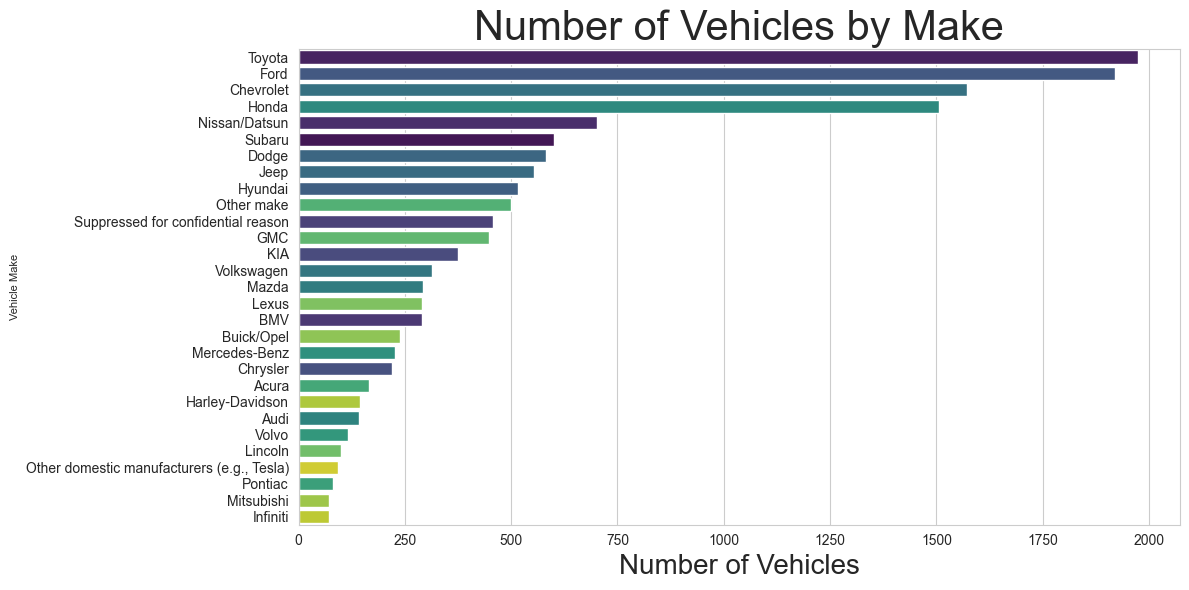

In [96]:
## Step 1: tell Python you are making a figure and what size you want
plt.figure(figsize = (12,6))

## Step 2: use sns.countplot to create the plot
# hint: sns.countplot(data=..., x=...) or sns.countplot(data=..., y=...) for horizontal
sns.countplot(data = nhts_data, y='make', order = nhts_data['make'].value_counts().index, palette = 'viridis', hue = 'make', legend = False)

## Step 3: add labels and title
plt.xlabel('Number of Vehicles', fontsize = 20)
plt.ylabel('Vehicle Make', fontsize = 8)
plt.title('Number of Vehicles by Make', fontsize = 30)

## Step 4: show the plot
plt.tight_layout()
plt.show()

<Figure size 2000x2000 with 0 Axes>

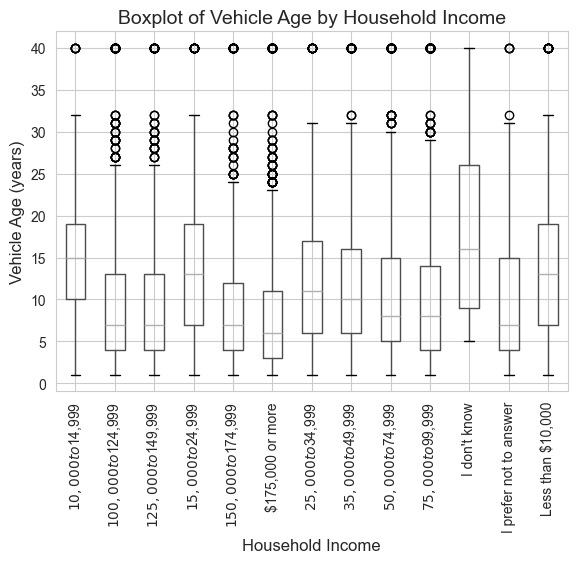

In [97]:
## Step 1: tell Python you are making a figure and what size you want the figure to be
plt.figure(figsize = (20,20))


## Step 2: call the type of plot and tell the function what variables you want to plot
boxplot = nhts_data.boxplot(column = 'vehicle_age', by = 'household_income')

plt.xticks(rotation = 90)

### the next two lines create your axis labels
plt.xlabel('Household Income', fontsize = 12)
plt.ylabel('Vehicle Age (years)', fontsize = 12)
### this line gives your plot a title
plt.title('Boxplot of Vehicle Age by Household Income', fontsize =14)
plt.suptitle('')


## Step 3: tell python to show the plot
plt.show()

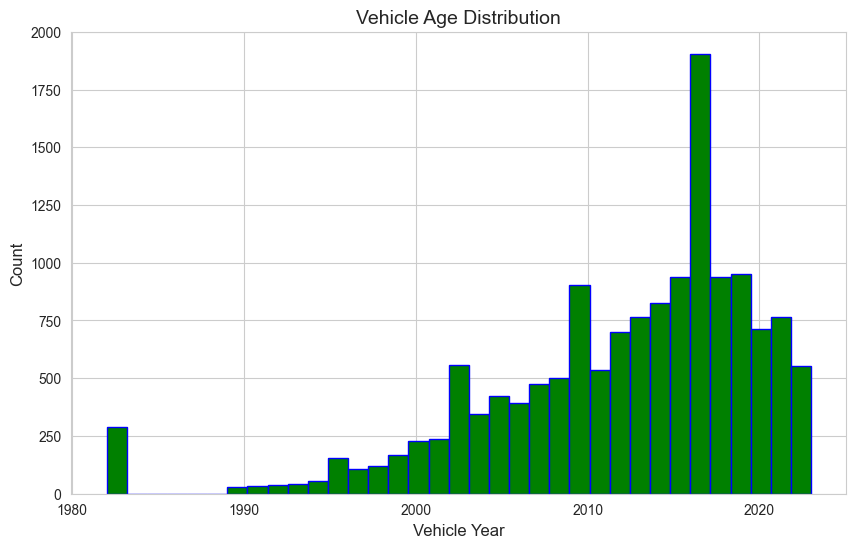

In [98]:
##Tell Python you are plotting a figure and how big you want the figure to be
plt.figure(figsize = (10,6))

## Tell Python what type of plot you want. Here, .hist() creates a histogram
plt.hist(nhts_data['vehicle_year'], bins = 35, color = 'green', edgecolor = 'blue')

# Then let's label. You'll notice you can change the fontsize of all your labels!
plt.ylabel('Count', fontsize = 12)
plt.xlabel('Vehicle Year', fontsize = 12)
plt.title('Vehicle Age Distribution', fontsize =14)

plt.show()

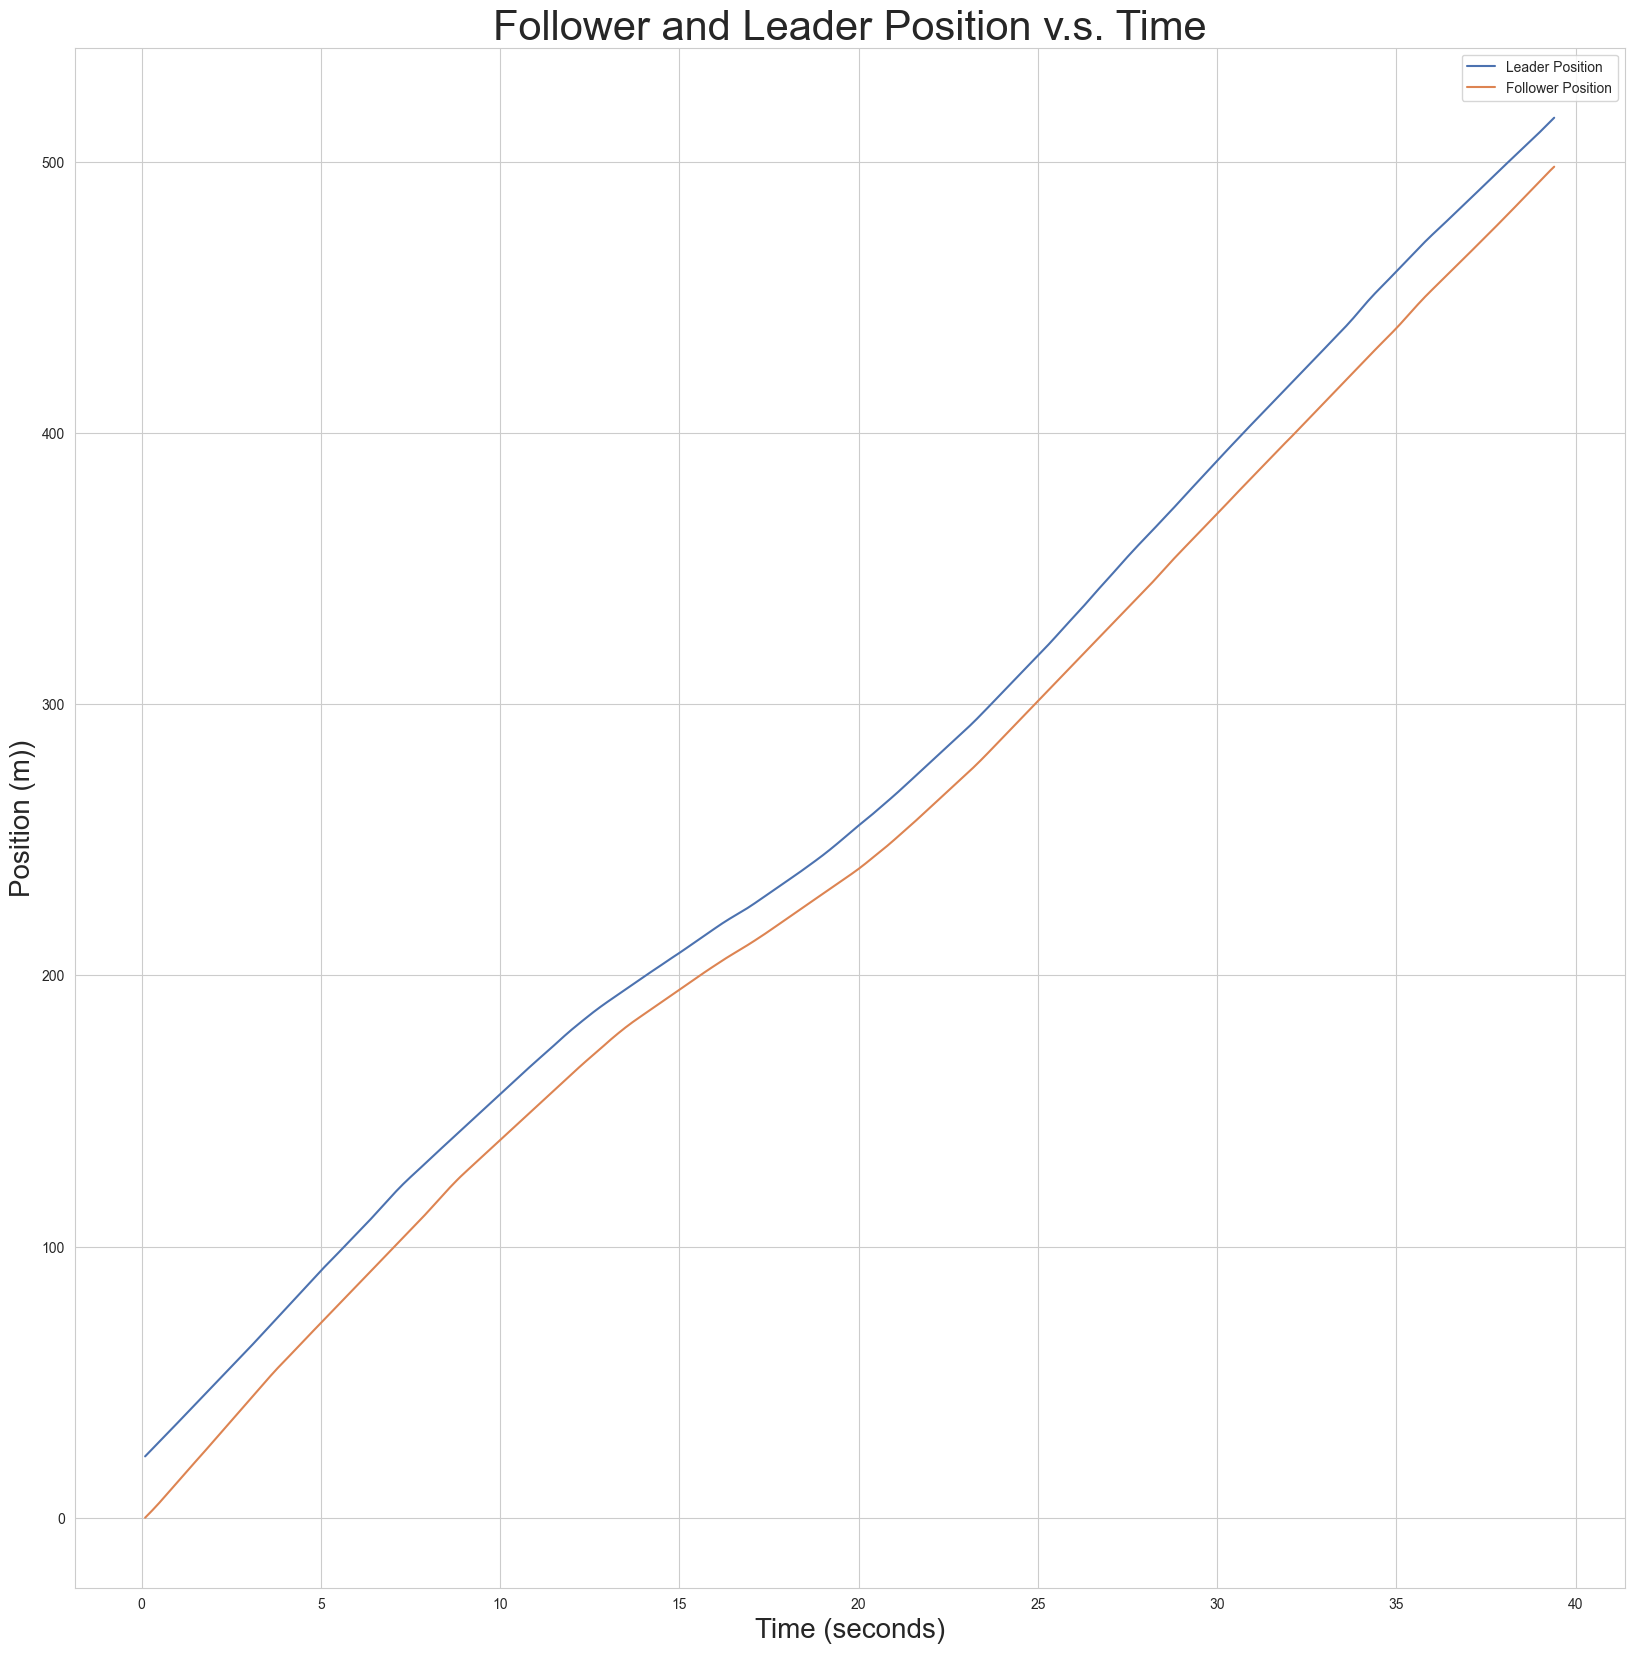

In [99]:
trajectory_number = 8  # vehicle pair x

# select the data based on the subset 

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number] 

# Plot the position of both vehicles over time
# follow similar steps of what we learned
# but here you need to plot two lines together:
    # one lineplot for leader position vs time
    # another lineplot for follower position vs time

plt.figure(figsize = (20,20))
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_position(m)', label='Leader Position')
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_position(m)', label='Follower Position')

plt.xlabel('Time (seconds)', fontsize = 20)
plt.ylabel('Position (m))', fontsize = 20)
plt.title('Follower and Leader Position v.s. Time', fontsize = 30)
plt.show()

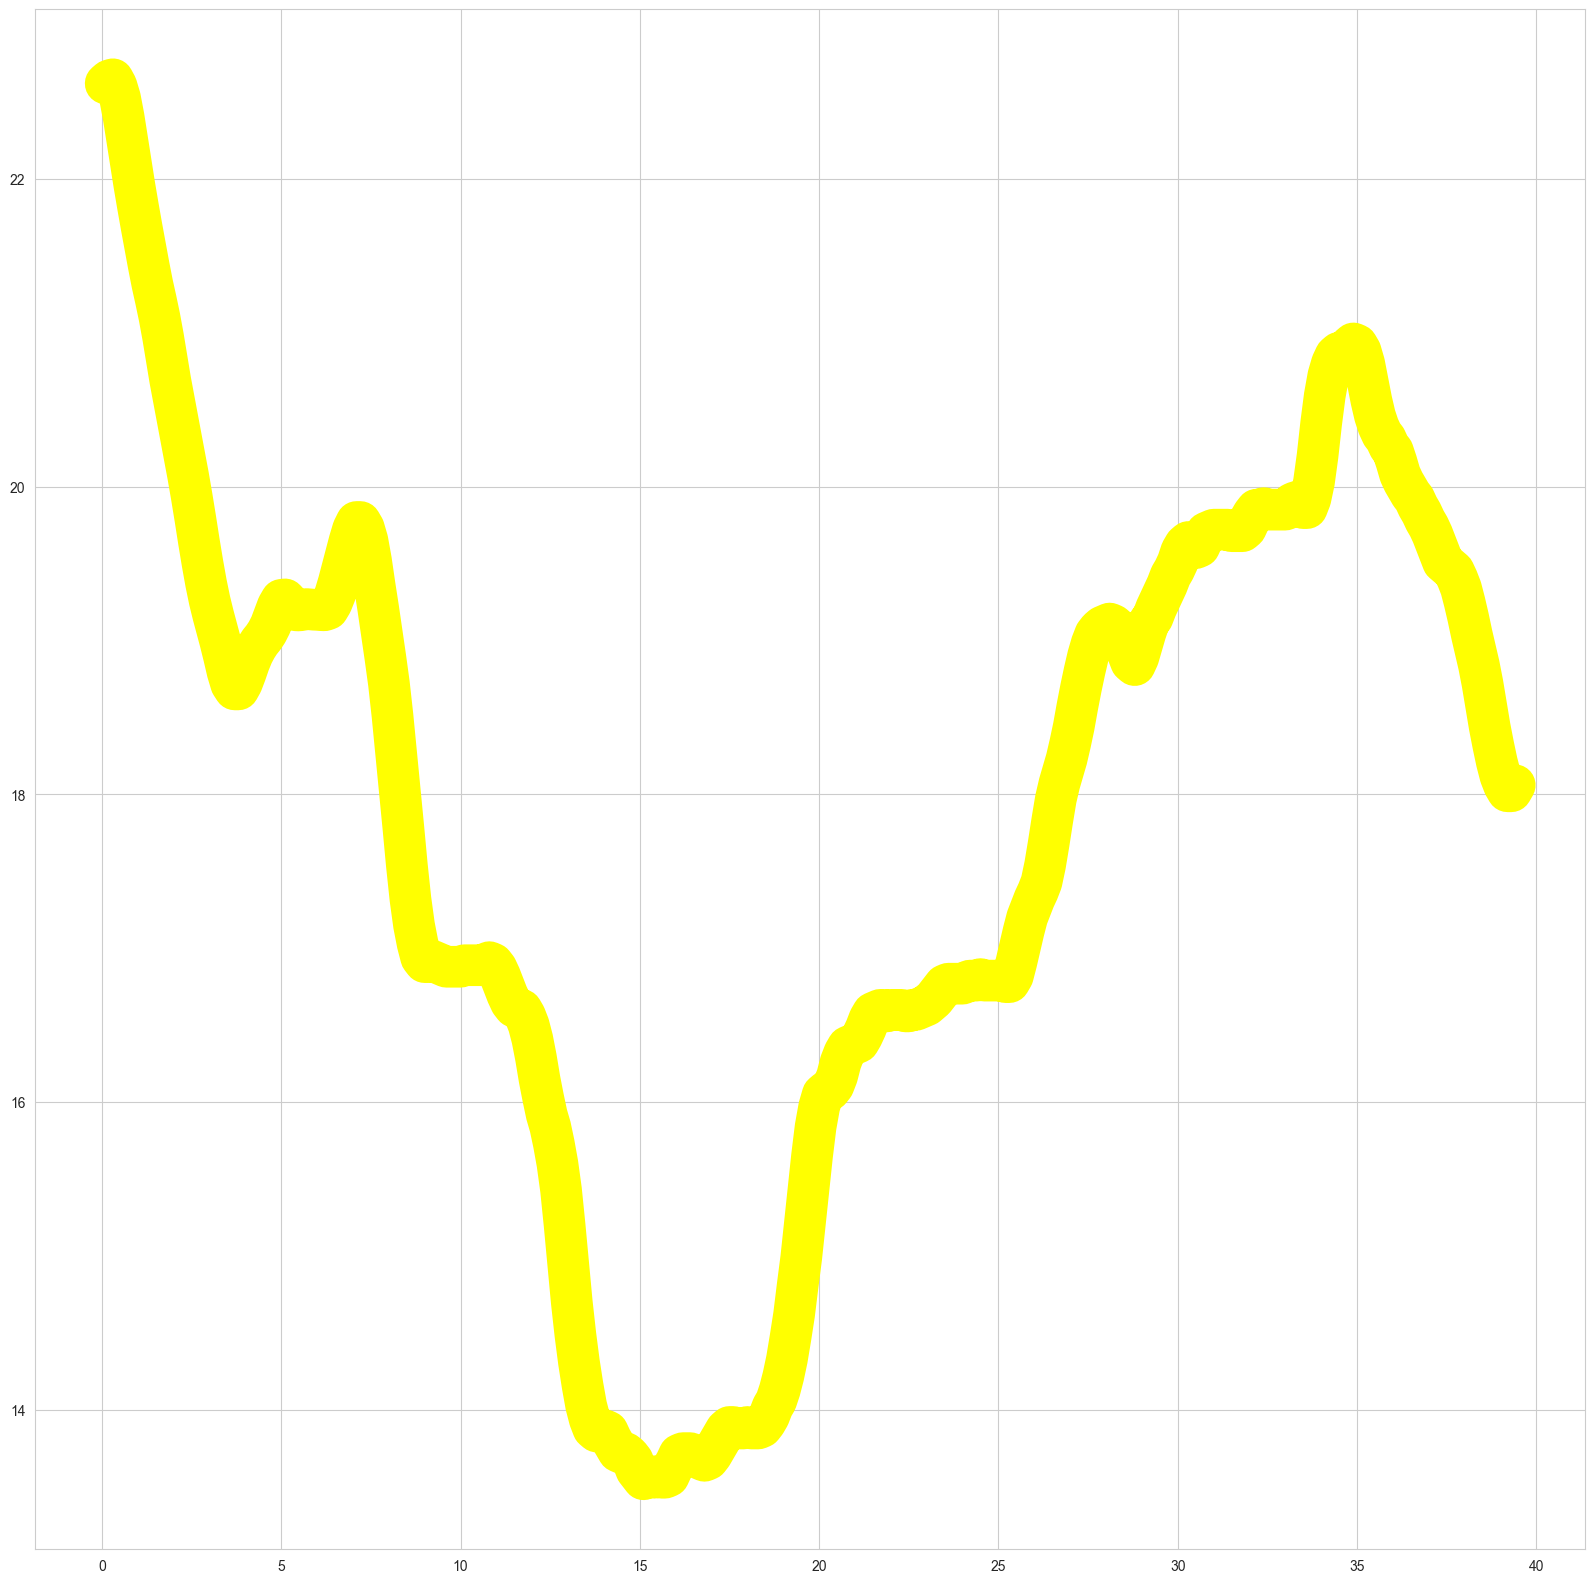

In [100]:
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values

gap_distance

plt.figure(figsize = (20, 20))
plt.plot(data_subset['Time'], gap_distance, color = 'yellow', linewidth = 30)

plt.show()

In [101]:
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    
    return acceleration

In [102]:
# Load the NGSIM data to get the leader vehicle trajectory
ngsim_data = pd.read_csv('NGSIM(in).csv')

# Select a trajectory pair
trajectory_number = 8
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)

# Extract the leader's position and speed over time
time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values
leader_acc = data_subset['leader_acc(m/s^2)'].values

# Identifying the time step in our data
dt = 0.1

In [103]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)    # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)        # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)        # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)  # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]     #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]      #this makes the starting value [0] same as the follower vehicle speed

In [104]:
# Run the IDM simulation
# We loop through each time step
for i in range(n_steps - 1): # -1 since the first element is known

    # Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]

    # Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i],gap,delta_v,v0,s0,T,a,b,delta)

    # Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]*dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i]*dt

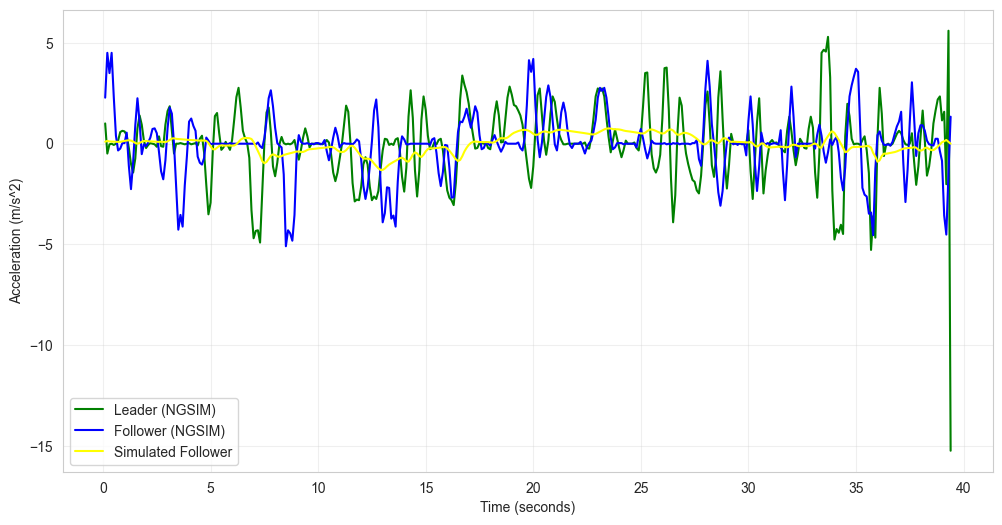

In [105]:
# Acceleration vs Time — Comparing leader, real follower, and simulated follower

plt.figure(figsize = (12,6))
plt.plot(time_data, leader_acc, label = 'Leader (NGSIM)', color = 'green')
plt.plot(time_data, data_subset['follower_acc(m/s^2)'].values, label = 'Follower (NGSIM)', color = 'blue')
plt.plot(time_data, sim_acc, label = 'Simulated Follower', color = 'yellow')
plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()
